---
## 1. Imports & Configuration

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import animation, rc
from IPython.display import HTML

random.seed(42)
np.random.seed(42)
rc('animation', html='jshtml')

print("Ready.")

Ready.


---
## 2. Maze Environment

In [ ]:
class Maze:
    """Grid-world maze with discrete state transitions."""

    def __init__(self, rows, cols, start_pos, goal_pos, walls):
        self.rows = rows
        self.cols = cols
        self.start_pos = start_pos
        self.goal_pos = goal_pos
        self.walls = set(walls)
        self.state = start_pos

    def reset(self):
        self.state = self.start_pos
        return self.state

    def step(self, action):
        """Actions: 0=Up, 1=Down, 2=Left, 3=Right → (next_state, reward, done)"""
        r, c = self.state
        moves = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        dr, dc = moves.get(action, (0, 0))
        ns = (r + dr, c + dc)

        if (0 <= ns[0] < self.rows and 0 <= ns[1] < self.cols and ns not in self.walls):
            self.state = ns

        done = self.state == self.goal_pos
        return self.state, (0 if done else -1), done

    def render(self, title="Maze"):
        grid = np.zeros((self.rows, self.cols))
        for w in self.walls:
            grid[w] = -1
        plt.figure(figsize=(6, 6))
        plt.imshow(grid, cmap='binary')
        plt.text(self.start_pos[1], self.start_pos[0], 'S',
                 ha='center', va='center', color='green', fontsize=20, fontweight='bold')
        plt.text(self.goal_pos[1], self.goal_pos[0], 'G',
                 ha='center', va='center', color='red', fontsize=20, fontweight='bold')
        plt.xticks(range(self.cols)); plt.yticks(range(self.rows))
        plt.grid(True); plt.title(title); plt.show()

    def get_neighbors(self, pos):
        """Return list of valid neighboring positions (used by ACO)."""
        r, c = pos
        neighbors = []
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < self.rows and 0 <= nc < self.cols and (nr,nc) not in self.walls:
                neighbors.append((nr, nc))
        return neighbors

---
## 3. Reinforcement Learning Agents

In [ ]:
class QLearningAgent:
    """Off-policy TD control using ε-greedy exploration."""

    def __init__(self, rows, cols, num_actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.q_table = np.zeros((rows, cols, num_actions))
        self.alpha, self.gamma, self.epsilon = alpha, gamma, epsilon
        self.num_actions = num_actions

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.num_actions - 1)
        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, done):
        best = np.argmax(self.q_table[next_state])
        target = reward + self.gamma * self.q_table[next_state][best] * (1 - done)
        self.q_table[state][action] += self.alpha * (target - self.q_table[state][action])


class SARSAAgent:
    """On-policy TD control using ε-greedy exploration."""

    def __init__(self, rows, cols, num_actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.q_table = np.zeros((rows, cols, num_actions))
        self.alpha, self.gamma, self.epsilon = alpha, gamma, epsilon
        self.num_actions = num_actions

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.num_actions - 1)
        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, next_action, done):
        target = reward + self.gamma * self.q_table[next_state][next_action] * (1 - done)
        self.q_table[state][action] += self.alpha * (target - self.q_table[state][action])


class BoltzmannQLearningAgent:
    """Q-Learning with Boltzmann (softmax) exploration instead of ε-greedy.

    Inspired by Boltzmann Machines (Unit III): action probabilities are computed
    using a temperature parameter τ — higher τ means more random exploration,
    lower τ means greedy exploitation of high-Q actions.
    """

    def __init__(self, rows, cols, num_actions, alpha=0.1, gamma=0.9, temperature=1.0):
        self.q_table = np.zeros((rows, cols, num_actions))
        self.alpha, self.gamma, self.temperature = alpha, gamma, temperature
        self.num_actions = num_actions

    def choose_action(self, state):
        q = self.q_table[state]
        # Boltzmann softmax: P(a) = exp(Q(a)/τ) / Σ exp(Q(a)/τ)
        exp_q = np.exp((q - np.max(q)) / self.temperature)  # subtract max for stability
        probs = exp_q / exp_q.sum()
        return int(np.random.choice(self.num_actions, p=probs))

    def update(self, state, action, reward, next_state, done):
        best = np.argmax(self.q_table[next_state])
        target = reward + self.gamma * self.q_table[next_state][best] * (1 - done)
        self.q_table[state][action] += self.alpha * (target - self.q_table[state][action])

---
## 4. Ant Colony Optimization (ACO)

ACO (Unit V) is a metaheuristic inspired by ant foraging behavior. Virtual ants traverse the maze leaving pheromone trails — shorter paths accumulate more pheromone, guiding future ants toward optimal routes.

In [ ]:
class AntColonyOptimizer:
    """Ant Colony Optimization for maze path-finding.

    Each iteration, K ants walk from start to goal using pheromone-guided
    probabilistic transitions. Pheromone evaporates over time and deposits
    on successful paths inversely proportional to path length.
    """

    def __init__(self, maze, num_ants=20, alpha=1.0, beta=3.0, evaporation=0.1, Q=100):
        self.maze = maze
        self.num_ants = num_ants
        self.alpha = alpha      # pheromone influence
        self.beta = beta        # heuristic (distance) influence
        self.evaporation = evaporation
        self.Q = Q              # pheromone deposit constant

        # Initialize pheromone matrix
        self.pheromone = np.ones((maze.rows, maze.cols, maze.rows, maze.cols)) * 0.1
        # Set walls to zero pheromone
        for w in maze.walls:
            self.pheromone[w[0], w[1], :, :] = 0
            self.pheromone[:, :, w[0], w[1]] = 0

        self.best_path = None
        self.best_length = float('inf')

    def _heuristic(self, pos):
        """Manhattan distance to goal (lower is better)."""
        return abs(pos[0] - self.maze.goal_pos[0]) + abs(pos[1] - self.maze.goal_pos[1])

    def _select_next(self, pos, visited):
        """Select next position using pheromone + heuristic probabilities."""
        neighbors = [n for n in self.maze.get_neighbors(pos) if n not in visited]
        if not neighbors:
            return None

        probs = []
        for n in neighbors:
            tau = self.pheromone[pos[0], pos[1], n[0], n[1]]
            eta = 1.0 / (self._heuristic(n) + 1e-6)  # avoid division by zero
            probs.append((tau ** self.alpha) * (eta ** self.beta))

        total = sum(probs)
        probs = [p / total for p in probs]
        return neighbors[np.random.choice(len(neighbors), p=probs)]

    def _run_ant(self):
        """Single ant constructs a path from start to goal."""
        path = [self.maze.start_pos]
        visited = {self.maze.start_pos}
        pos = self.maze.start_pos
        max_steps = self.maze.rows * self.maze.cols * 2

        for _ in range(max_steps):
            if pos == self.maze.goal_pos:
                return path
            nxt = self._select_next(pos, visited)
            if nxt is None:
                return None  # ant is stuck
            path.append(nxt)
            visited.add(nxt)
            pos = nxt

        return None  # exceeded max steps

    def fit(self, iterations=500):
        """Run ACO for given iterations, return history of best path lengths."""
        history = []

        for it in range(iterations):
            # All ants construct paths
            paths = []
            for _ in range(self.num_ants):
                path = self._run_ant()
                if path is not None:
                    paths.append(path)

            # Evaporate pheromone
            self.pheromone *= (1 - self.evaporation)

            # Deposit pheromone on successful paths
            for path in paths:
                length = len(path)
                deposit = self.Q / length
                for i in range(len(path) - 1):
                    r1, c1 = path[i]
                    r2, c2 = path[i+1]
                    self.pheromone[r1, c1, r2, c2] += deposit

                # Track best
                if length < self.best_length:
                    self.best_length = length
                    self.best_path = path

            # Record best length (use best_length if found, else penalize)
            history.append(self.best_length if self.best_length != float('inf') else -50)

        # Convert to reward-like scale (negate so higher = better, for comparison)
        reward_history = [-(l - 1) for l in history]  # path_len=10 → reward=-9 (closer to 0 is better)
        return reward_history

    def get_pheromone_map(self):
        """Return pheromone intensity per cell for visualization."""
        phero_map = np.zeros((self.maze.rows, self.maze.cols))
        for r in range(self.maze.rows):
            for c in range(self.maze.cols):
                if (r, c) not in self.maze.walls:
                    phero_map[r, c] = np.sum(self.pheromone[r, c, :, :])
        return phero_map

    def record_trajectory(self):
        """Return the best found path as a trajectory."""
        return self.best_path if self.best_path else [self.maze.start_pos, self.maze.goal_pos]

---
## 5. Training Functions

In [ ]:
def train_rl_agent(agent, maze, episodes=500, max_steps=200):
    """Train an RL agent, return reward history per episode."""
    history = []
    for _ in range(episodes):
        state = maze.reset()
        total = 0
        action = agent.choose_action(state)
        for _ in range(max_steps):
            ns, reward, done = maze.step(action)
            if isinstance(agent, (QLearningAgent, BoltzmannQLearningAgent)):
                agent.update(state, action, reward, ns, done)
                na = agent.choose_action(ns)
            else:  # SARSA
                na = agent.choose_action(ns)
                agent.update(state, action, reward, ns, na, done)
            state, action = ns, na
            total += reward
            if done:
                break
        history.append(total)
    return history


def compute_success_rate(agent, maze, num_agents=1, trials=100, max_steps=200):
    """Compute % of episodes where agent reaches the goal."""
    successes = 0
    if num_agents == 0:  # ACO case
        return 100.0 if agent.best_path else 0.0
    for _ in range(trials):
        state = maze.reset()
        for _ in range(max_steps):
            action = agent.choose_action(state)
            state, _, done = maze.step(action)
            if done:
                successes += 1
                break
    return 100.0 * successes / trials

---
## 6. Visualization Utilities

In [ ]:
def plot_learning_curves(histories, labels, title="Learning Progress"):
    plt.figure(figsize=(10, 5))
    for h, l in zip(histories, labels):
        plt.plot(h, label=l, alpha=0.75)
    plt.xlabel("Episode / Iteration")
    plt.ylabel("Total Reward")
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_q_values_and_policy(q_table, maze, title="Q-Values & Policy"):
    rows, cols = maze.rows, maze.cols
    max_q = np.max(q_table, axis=2)
    plt.figure(figsize=(8, 6))
    sns.heatmap(max_q, annot=True, fmt=".1f", cmap="viridis",
                cbar_kws={'label': 'Max Q-Value'})
    u, v = np.zeros((rows, cols)), np.zeros((rows, cols))
    arrow = {0: (0, 0.5), 1: (0, -0.5), 2: (-0.5, 0), 3: (0.5, 0)}
    for r in range(rows):
        for c in range(cols):
            if (r, c) in {maze.goal_pos} | maze.walls:
                continue
            u[r, c], v[r, c] = arrow[int(np.argmax(q_table[r, c]))]
    y, x = np.meshgrid(np.arange(rows), np.arange(cols), indexing='ij')
    plt.quiver(x+0.5, y+0.5, u, -v, color='white', scale=10, width=0.01)
    plt.title(title)
    plt.tight_layout(); plt.show()


def plot_pheromone_map(aco, maze, title="ACO Pheromone Trail"):
    """Visualize pheromone intensity across the maze."""
    phero = aco.get_pheromone_map()
    grid = np.zeros((maze.rows, maze.cols))
    for w in maze.walls:
        grid[w] = np.nan
    plt.figure(figsize=(8, 6))
    sns.heatmap(phero, annot=True, fmt=".1f", cmap="YlOrRd",
                mask=np.isnan(grid), cbar_kws={'label': 'Pheromone Intensity'})
    plt.title(title)
    plt.tight_layout(); plt.show()


def plot_comparison_bar(metrics, labels, title="Comparison"):
    """Horizontal bar chart for comparing algorithms."""
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
    plt.figure(figsize=(10, 4))
    bars = plt.barh(labels, metrics, color=colors[:len(labels)])
    plt.xlabel("Success Rate (%)")
    plt.title(title)
    for bar, val in zip(bars, metrics):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center')
    plt.xlim(0, 115)
    plt.tight_layout(); plt.show()


def animate_trajectory(maze, trajectory):
    fig, ax = plt.subplots(figsize=(6, 6))
    grid = np.zeros((maze.rows, maze.cols))
    for w in maze.walls:
        grid[w] = -1
    ax.imshow(grid, cmap='binary')
    ax.text(maze.start_pos[1], maze.start_pos[0], 'S',
            ha='center', va='center', color='green', fontsize=20, fontweight='bold')
    ax.text(maze.goal_pos[1], maze.goal_pos[0], 'G',
            ha='center', va='center', color='red', fontsize=20, fontweight='bold')
    dot = plt.Circle((trajectory[0][1], trajectory[0][0]), 0.3, color='blue')
    ax.add_patch(dot)
    def update(frame):
        dot.center = (trajectory[frame][1], trajectory[frame][0])
        return dot,
    anim = animation.FuncAnimation(fig, update, frames=len(trajectory), interval=200, blit=True)
    plt.close(fig)
    return anim


def record_rl_trajectory(agent, maze, max_steps=100):
    state = maze.reset()
    traj = [state]
    for _ in range(max_steps):
        action = agent.choose_action(state)
        state, _, done = maze.step(action)
        traj.append(state)
        if done:
            break
    return traj

---
## 7. Baseline Comparison (5×5 Maze)

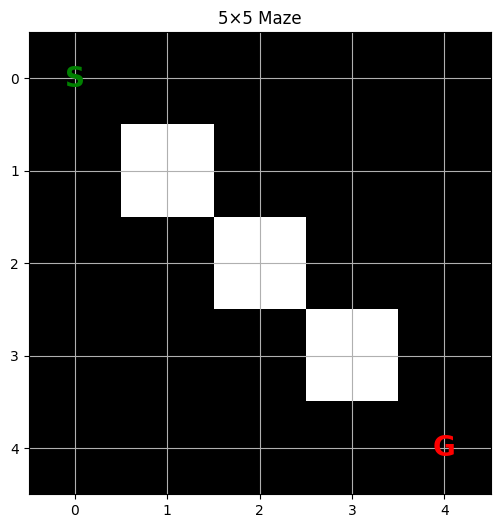

Training Q-Learning...
Training SARSA...
Training Boltzmann Q-Learning...
Running Ant Colony Optimization...


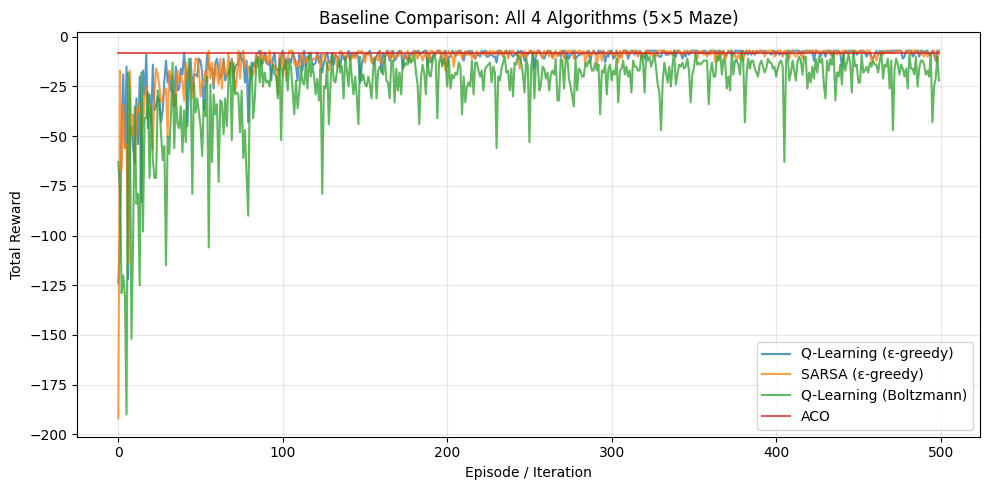

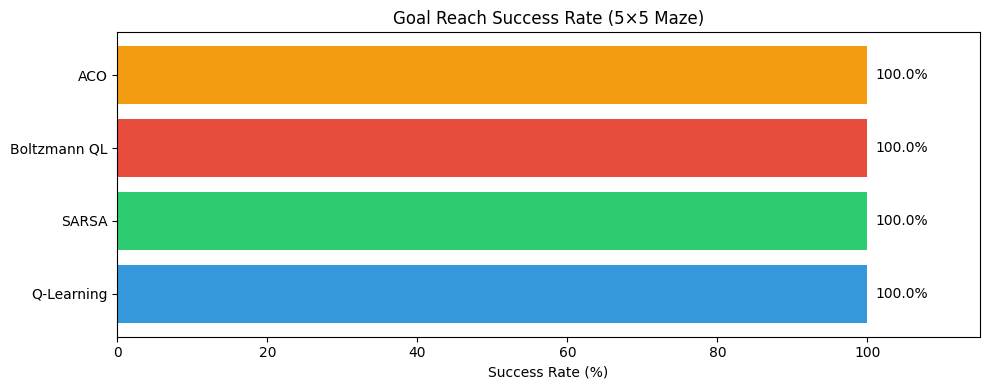

In [ ]:
# Environment
walls_5x5 = [(1, 1), (2, 2), (3, 3)]
maze_5x5 = Maze(5, 5, start_pos=(0, 0), goal_pos=(4, 4), walls=walls_5x5)
maze_5x5.render("5×5 Maze")

# Initialize all 4 agents
ql = QLearningAgent(5, 5, 4, alpha=0.1, gamma=0.9, epsilon=0.1)
sarsa = SARSAAgent(5, 5, 4, alpha=0.1, gamma=0.9, epsilon=0.1)
boltz = BoltzmannQLearningAgent(5, 5, 4, alpha=0.1, gamma=0.9, temperature=1.0)
aco = AntColonyOptimizer(maze_5x5, num_ants=20, evaporation=0.1, Q=100)

# Train RL agents
print("Training Q-Learning...")
ql_hist = train_rl_agent(ql, maze_5x5, episodes=500)

print("Training SARSA...")
sarsa_hist = train_rl_agent(sarsa, maze_5x5, episodes=500)

print("Training Boltzmann Q-Learning...")
boltz_hist = train_rl_agent(boltz, maze_5x5, episodes=500)

# Train ACO
print("Running Ant Colony Optimization...")
aco_hist = aco.fit(iterations=500)

# Plot all 4 learning curves
plot_learning_curves(
    [ql_hist, sarsa_hist, boltz_hist, aco_hist],
    ["Q-Learning (ε-greedy)", "SARSA (ε-greedy)", "Q-Learning (Boltzmann)", "ACO"],
    title="Baseline Comparison: All 4 Algorithms (5×5 Maze)"
)

# Success rates
labels = ["Q-Learning", "SARSA", "Boltzmann QL", "ACO"]
rates = [
    compute_success_rate(ql, maze_5x5),
    compute_success_rate(sarsa, maze_5x5),
    compute_success_rate(boltz, maze_5x5),
    compute_success_rate(aco, maze_5x5, num_agents=0)
]
plot_comparison_bar(rates, labels, title="Goal Reach Success Rate (5×5 Maze)")

---
## 8. RL Agents: Policy Visualization (5×5)

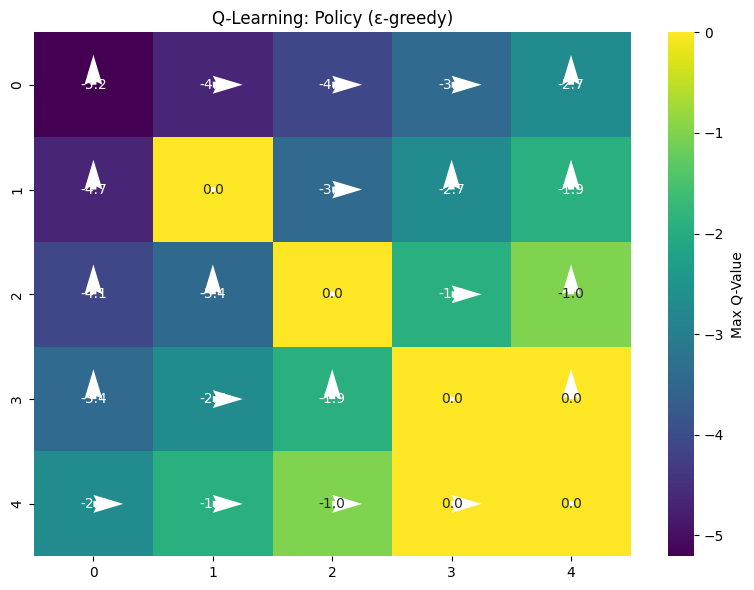

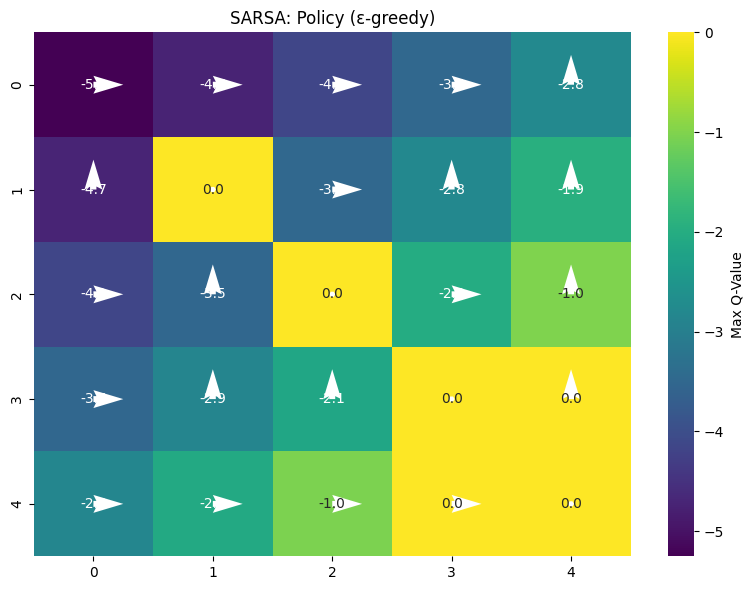

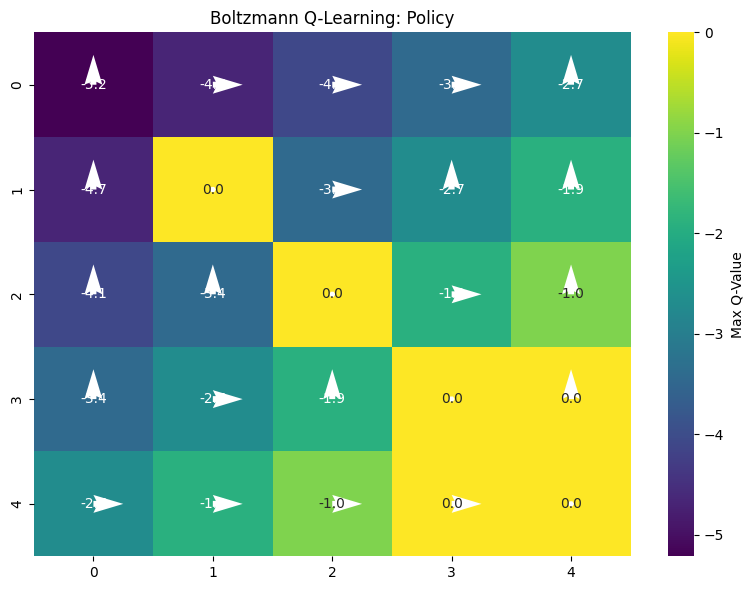

In [ ]:
plot_q_values_and_policy(ql.q_table, maze_5x5, title="Q-Learning: Policy (ε-greedy)")
plot_q_values_and_policy(sarsa.q_table, maze_5x5, title="SARSA: Policy (ε-greedy)")
plot_q_values_and_policy(boltz.q_table, maze_5x5, title="Boltzmann Q-Learning: Policy")

---
## 9. ACO: Pheromone Map (5×5)

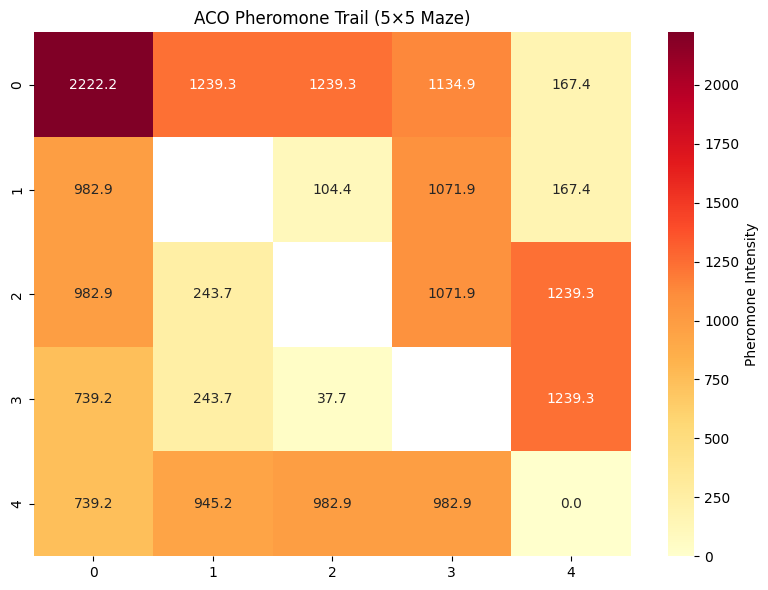

ACO best path length: 9
ACO best path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]


In [ ]:
plot_pheromone_map(aco, maze_5x5, title="ACO Pheromone Trail (5×5 Maze)")

print(f"ACO best path length: {aco.best_length}")
print(f"ACO best path: {aco.best_path}")

---
## 10. Sensitivity Analysis — RL Agents (γ sweep)

γ = 0.1 ... done.
γ = 0.5 ... done.
γ = 0.9 ... done.
γ = 0.99 ... done.


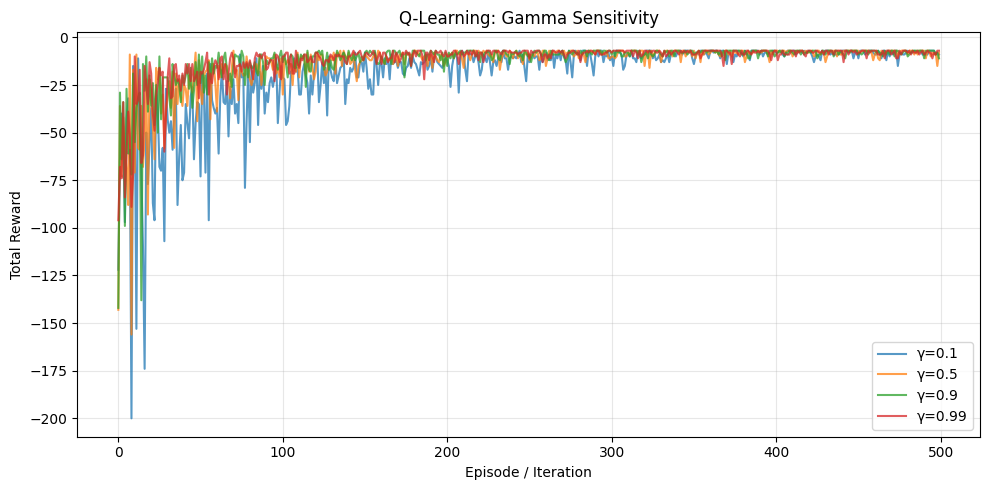

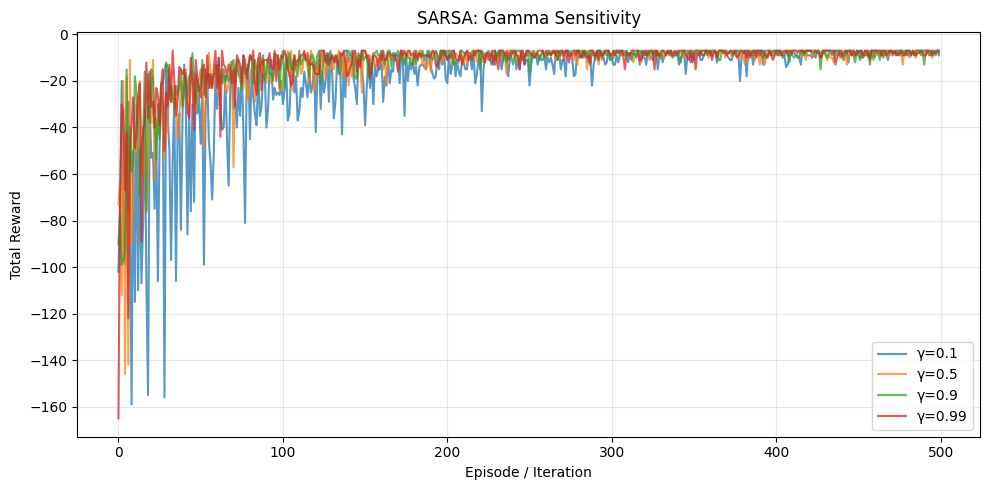

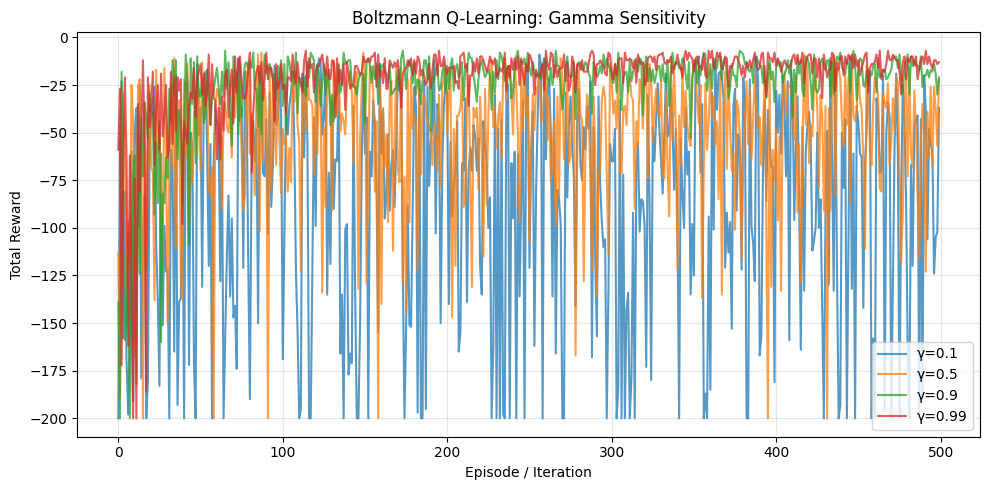

In [ ]:
gamma_values = [0.1, 0.5, 0.9, 0.99]
ql_hists, sarsa_hists, boltz_hists = [], [], []

for g in gamma_values:
    print(f"γ = {g} ...", end=" ")
    ql_hists.append(train_rl_agent(QLearningAgent(5,5,4, alpha=0.1, gamma=g), maze_5x5, 500))
    sarsa_hists.append(train_rl_agent(SARSAAgent(5,5,4, alpha=0.1, gamma=g), maze_5x5, 500))
    boltz_hists.append(train_rl_agent(BoltzmannQLearningAgent(5,5,4, alpha=0.1, gamma=g), maze_5x5, 500))
    print("done.")

g_labels = [f"γ={g}" for g in gamma_values]

plot_learning_curves(ql_hists, g_labels, title="Q-Learning: Gamma Sensitivity")
plot_learning_curves(sarsa_hists, g_labels, title="SARSA: Gamma Sensitivity")
plot_learning_curves(boltz_hists, g_labels, title="Boltzmann Q-Learning: Gamma Sensitivity")

**Observations:**

| γ | Behavior |
|---|----------|
| **0.1** | Myopic — agents focus on immediate rewards, low total reward |
| **0.5** | Moderate foresight, faster convergence but suboptimal |
| **0.9** | Best balance of convergence speed and policy quality |
| **0.99** | Near-optimal but slower early convergence (Q-value propagation delay) |

---
## 11. Sensitivity Analysis — Boltzmann Temperature (τ)

τ = 0.1 ... done.
τ = 0.5 ... done.
τ = 1.0 ... done.
τ = 2.0 ... done.
τ = 5.0 ... done.


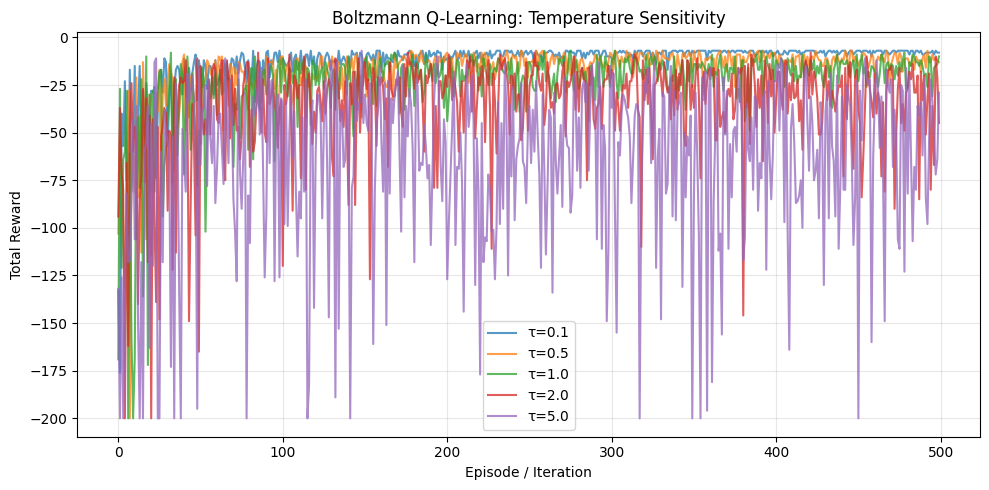

In [ ]:
tau_values = [0.1, 0.5, 1.0, 2.0, 5.0]
tau_hists = []

for tau in tau_values:
    print(f"τ = {tau} ...", end=" ")
    tau_hists.append(train_rl_agent(
        BoltzmannQLearningAgent(5,5,4, alpha=0.1, gamma=0.9, temperature=tau),
        maze_5x5, 500
    ))
    print("done.")

tau_labels = [f"τ={t}" for t in tau_values]
plot_learning_curves(tau_hists, tau_labels, title="Boltzmann Q-Learning: Temperature Sensitivity")

**Observations:**

| τ | Behavior |
|---|----------|
| **0.1** | Near-greedy — almost always picks highest Q action, fast convergence but may miss alternatives |
| **0.5** | Mild exploration, good convergence |
| **1.0** | Balanced exploration-exploitation (default) |
| **2.0** | More random exploration, slower but thorough |
| **5.0** | Nearly uniform random — very slow convergence |

This directly connects to **Boltzmann Machines (Unit III)**: the temperature parameter controls the randomness of action selection, analogous to simulated annealing.

---
## 12. Sensitivity Analysis — ACO Evaporation Rate (ρ)

ρ = 0.05 ... best_len=9
ρ = 0.1 ... best_len=9
ρ = 0.3 ... best_len=9
ρ = 0.5 ... best_len=9


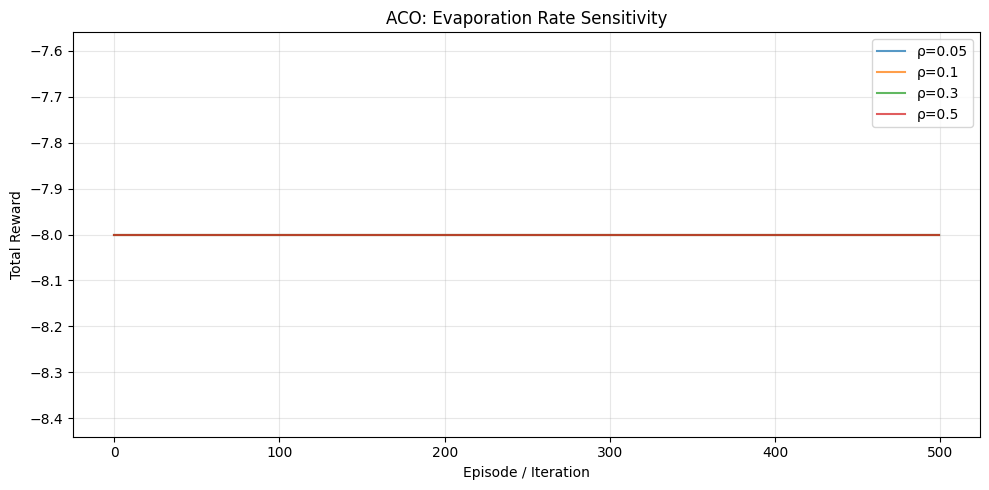

In [ ]:
evap_values = [0.05, 0.1, 0.3, 0.5]
aco_hists = []

for rho in evap_values:
    print(f"ρ = {rho} ...", end=" ")
    a = AntColonyOptimizer(maze_5x5, num_ants=20, evaporation=rho, Q=100)
    aco_hists.append(a.fit(iterations=500))
    print(f"best_len={a.best_length}")

rho_labels = [f"ρ={r}" for r in evap_values]
plot_learning_curves(aco_hists, rho_labels, title="ACO: Evaporation Rate Sensitivity")

**Observations:**

| Evaporation (ρ) | Behavior |
|-----------------|----------|
| **0.05** | Slow forgetting — pheromone accumulates, good for finding optimal path but slow to abandon bad ones |
| **0.1** | Balanced (default) |
| **0.3** | Faster adaptation, may forget good paths too quickly |
| **0.5** | Very aggressive evaporation — nearly random search each iteration |

---
## 13. Generalization Test: Bridge Maze (3×7)

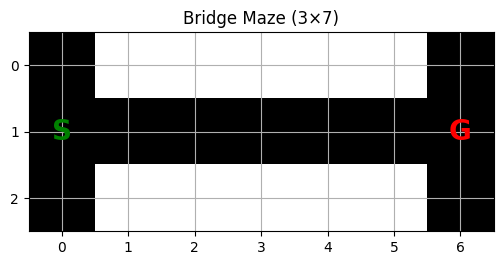

Training Q-Learning (Bridge)...
Training SARSA (Bridge)...
Training Boltzmann QL (Bridge)...
Running ACO (Bridge)...


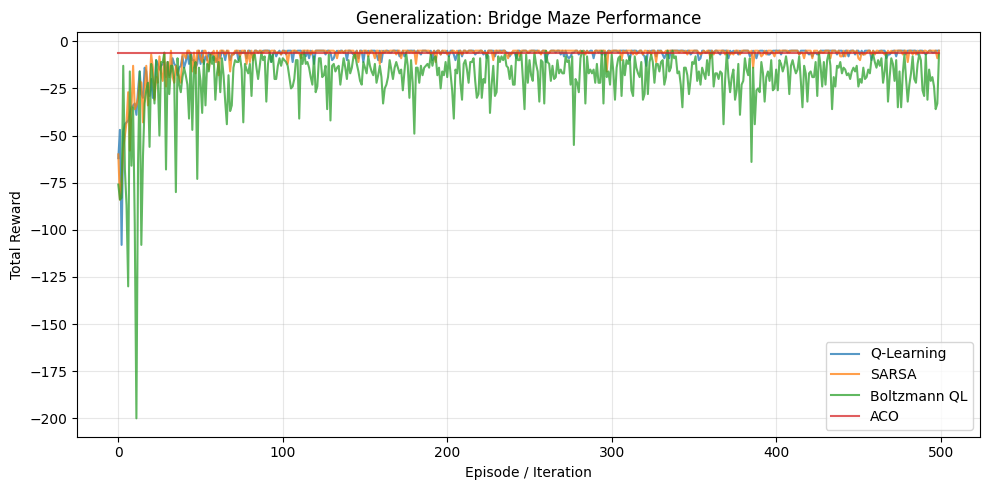

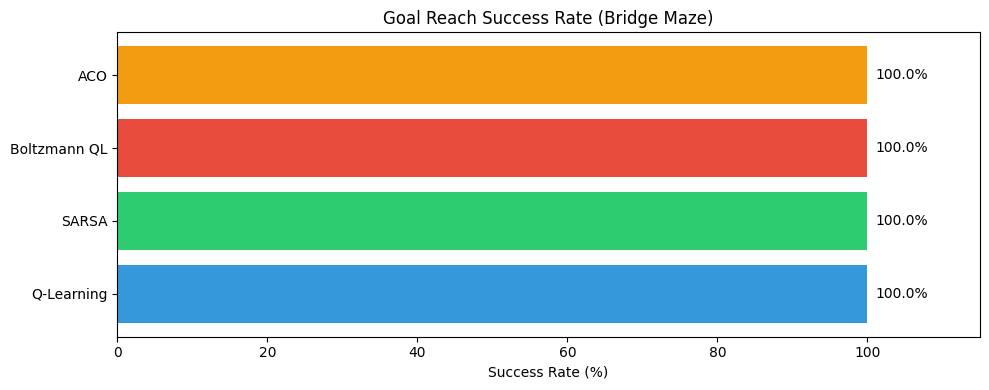

In [ ]:
# Environment: 1-cell-wide corridor
bridge_walls = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (2, 1), (2, 2), (2, 3), (2, 4), (2, 5)
]
maze_bridge = Maze(3, 7, start_pos=(1, 0), goal_pos=(1, 6), walls=bridge_walls)
maze_bridge.render("Bridge Maze (3×7)")

# Train all agents on Bridge maze
ql_b = QLearningAgent(3, 7, 4, alpha=0.1, gamma=0.9)
sarsa_b = SARSAAgent(3, 7, 4, alpha=0.1, gamma=0.9)
boltz_b = BoltzmannQLearningAgent(3, 7, 4, alpha=0.1, gamma=0.9, temperature=1.0)
aco_b = AntColonyOptimizer(maze_bridge, num_ants=20, evaporation=0.1)

print("Training Q-Learning (Bridge)...")
ql_b_hist = train_rl_agent(ql_b, maze_bridge, 500)

print("Training SARSA (Bridge)...")
sarsa_b_hist = train_rl_agent(sarsa_b, maze_bridge, 500)

print("Training Boltzmann QL (Bridge)...")
boltz_b_hist = train_rl_agent(boltz_b, maze_bridge, 500)

print("Running ACO (Bridge)...")
aco_b_hist = aco_b.fit(iterations=500)

# Learning curves
plot_learning_curves(
    [ql_b_hist, sarsa_b_hist, boltz_b_hist, aco_b_hist],
    ["Q-Learning", "SARSA", "Boltzmann QL", "ACO"],
    title="Generalization: Bridge Maze Performance"
)

# Success rates
bridge_rates = [
    compute_success_rate(ql_b, maze_bridge),
    compute_success_rate(sarsa_b, maze_bridge),
    compute_success_rate(boltz_b, maze_bridge),
    compute_success_rate(aco_b, maze_bridge, num_agents=0)
]
plot_comparison_bar(bridge_rates, labels, title="Goal Reach Success Rate (Bridge Maze)")

---
## 14. Policies & Pheromone Map (Bridge Maze)

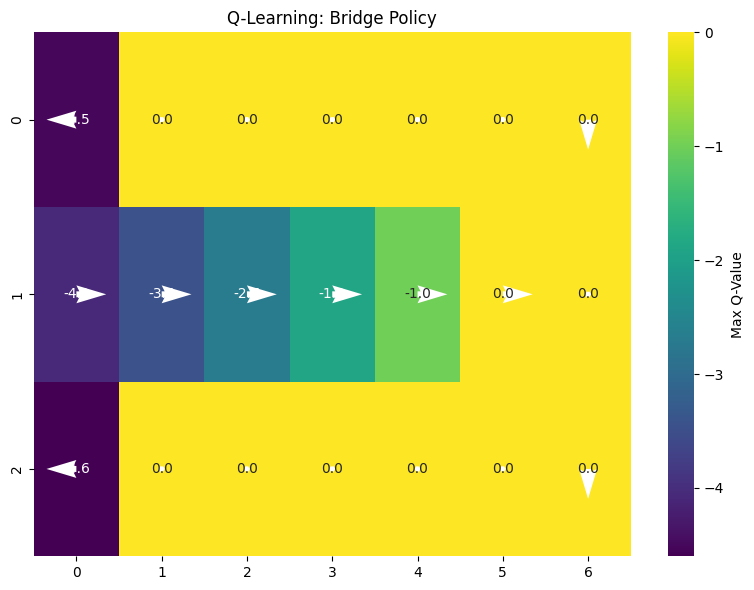

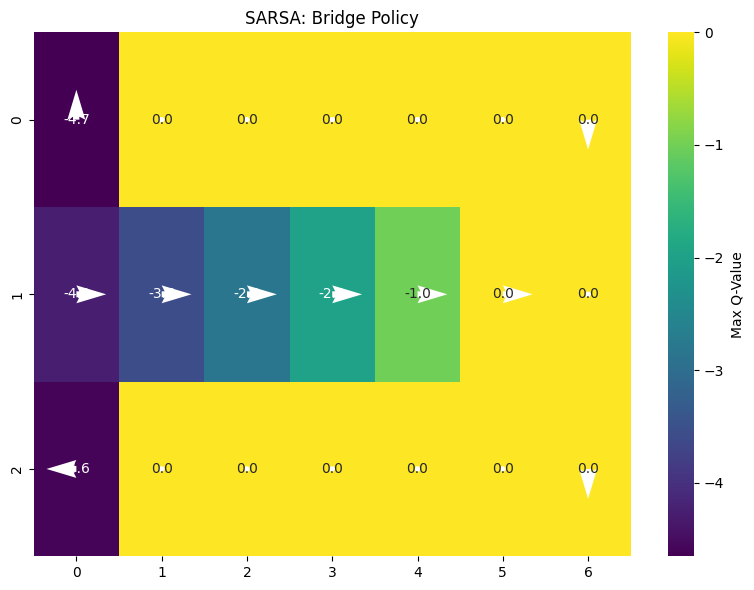

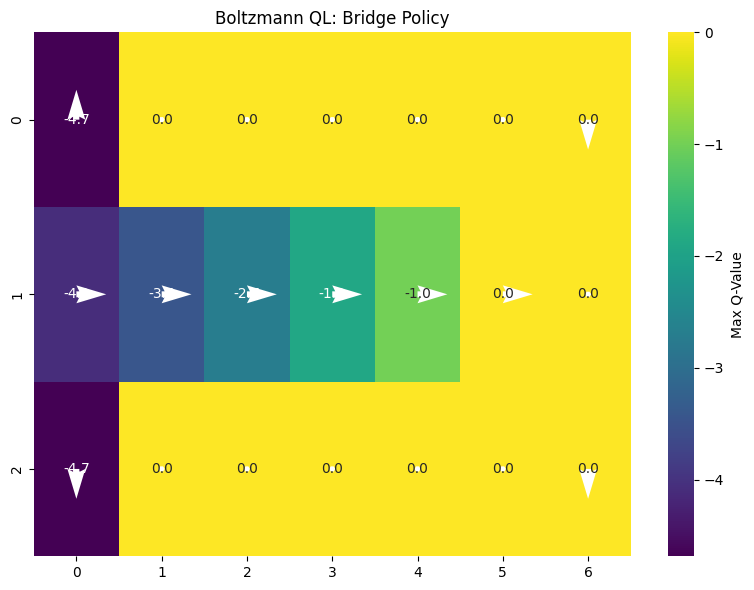

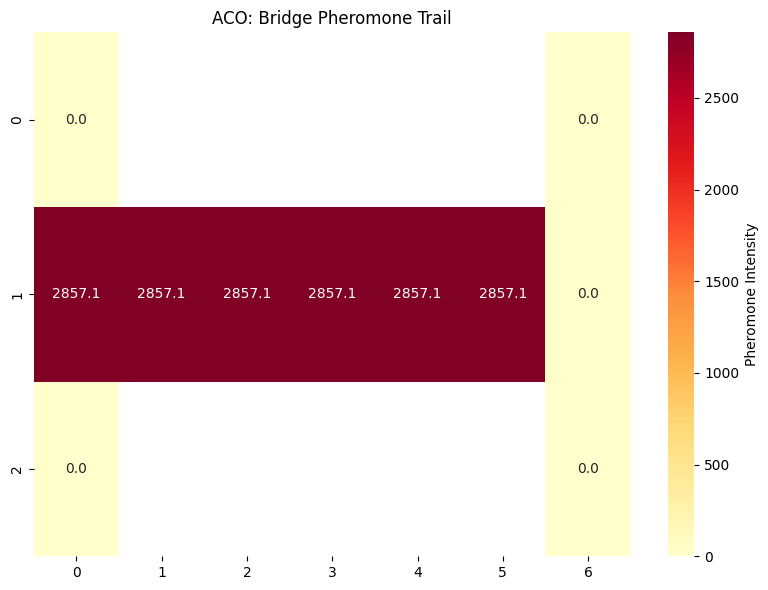

In [ ]:
plot_q_values_and_policy(ql_b.q_table, maze_bridge, title="Q-Learning: Bridge Policy")
plot_q_values_and_policy(sarsa_b.q_table, maze_bridge, title="SARSA: Bridge Policy")
plot_q_values_and_policy(boltz_b.q_table, maze_bridge, title="Boltzmann QL: Bridge Policy")
plot_pheromone_map(aco_b, maze_bridge, title="ACO: Bridge Pheromone Trail")

---
## 15. Path Animation (Best Agent on Bridge)

In [ ]:
print("Recording best trajectory on Bridge Maze...")
traj = record_rl_trajectory(sarsa_b, maze_bridge)
anim = animate_trajectory(maze_bridge, traj)
anim

Recording best trajectory on Bridge Maze...


---
## 16. Summary & Key Takeaways

In [ ]:
print("="*60)
print("ALGORITHM COMPARISON SUMMARY")
print("="*60)
print(f"{'Algorithm':<25} {'5x5 Success':>12} {'Bridge Success':>14} {'Category':<20}")
print("-"*60)

algorithms = [
    ("Q-Learning (ε-greedy)", rates[0], bridge_rates[0], "RL (Off-Policy)"),
    ("SARSA (ε-greedy)", rates[1], bridge_rates[1], "RL (On-Policy)"),
    ("Q-Learning (Boltzmann)", rates[2], bridge_rates[2], "RL + Boltzmann"),
    ("Ant Colony Optimization", rates[3], bridge_rates[3], "Swarm Intelligence"),
]

for name, r5, rb, cat in algorithms:
    print(f"{name:<25} {r5:>11.1f}% {rb:>13.1f}% {cat:<20}")

print("="*60)

ALGORITHM COMPARISON SUMMARY
Algorithm                  5x5 Success Bridge Success Category            
------------------------------------------------------------
Q-Learning (ε-greedy)           100.0%         100.0% RL (Off-Policy)     
SARSA (ε-greedy)                100.0%         100.0% RL (On-Policy)      
Q-Learning (Boltzmann)          100.0%         100.0% RL + Boltzmann      
Ant Colony Optimization         100.0%         100.0% Swarm Intelligence  
